Algoritmos Genéticos y Optimización Heurística - UTN-FRT
# **Trabajo Práctico N°5**
##**Tema**: Aplicaciones de AG##

Objetivo: Aplicar heurísticas a problemas reales.


*   Mamani, Pablo Ariel
*   Monteros, Maria Milagros


*   Rocha, Felipe





## Ejercicio 1

Utilice el AG Simple para resolver el problema del viajante o TSP (Travelling Salesman Problem):
* Se tienen **N** ciudades por las cuales el viajante debe pasar.
* El viajante pasa sólo una vez por cada ciudad.
* Inicia en una ciudad, hace su recorrido y vuelve a la ciudad de inicio.
* El objetivo es encontrar el camino más corto que el viajante debe recorrer para pasar por todas las ciudades.

El caso particular que usted debe resolver consiste de 14 ciudades, cuyas coordenadas son las siguientes (tomar la primera como punto de partida):

Ciudades para el problema de TSP


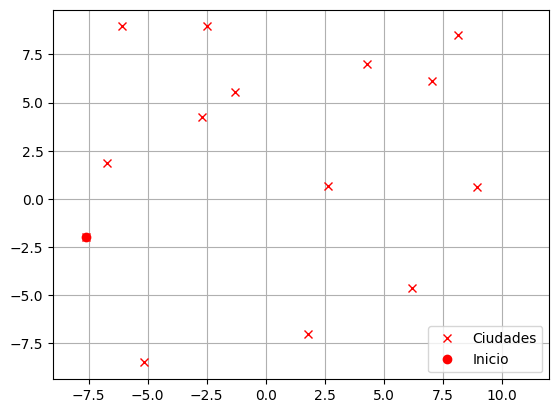

In [47]:
coordenadas = [
  [-7.5984,-1.9725],
  [-6.7323, 1.8807],
  [-2.7165, 4.2661],
  [-1.2992, 5.5505],
  [-6.1024, 8.9450],
  [-2.4803, 8.9450],
  [ 4.2913, 7.0183],
  [ 7.0472, 6.1009],
  [ 8.1496, 8.4862],
  [ 8.9370, 0.5963],
  [ 2.6378, 0.6881],
  [ 6.1811,-4.6330],
  [ 1.7717,-7.0183],
  [-5.1575,-8.4862]
]

x = [c[0] for c in coordenadas]
y = [c[1] for c in coordenadas]
import matplotlib.pyplot as plt
plt.plot(x, y, 'xr', label='Ciudades');
plt.plot(x[0], y[0], 'or', label='Inicio');
plt.legend()
plt.grid()
plt.xlim([-9,12])
print("Ciudades para el problema de TSP")

El algoritmo requiere conocer las distancias entre las ciudades para poder calcular la distancia total recorrida. Para ello se propone la siguiente funcion para calcular la distancia entre una ciudad *i* y *j*:

In [48]:
import math
def distancia(coord_i, coord_j):
  #distancia Euclidea
  return math.sqrt((coord_i[0]-coord_j[0])**2 + (coord_i[1]-coord_j[1])**2)

#ejemplo
ciudad_i = 1
ciudad_j = 5
d = distancia(coordenadas[ciudad_i], coordenadas[ciudad_j])
print("Distancia entre ciudad %d y %d; %f"%(ciudad_i, ciudad_j, d))

Distancia entre ciudad 1 y 5; 8.245231


Se pide:
1. Determinar una codificación adecuada (forma de representar las soluciones  para el problema).
2. Definir las restricciones para los valores en la solución (determinar la matriz de *Bounds*).
3. En base a la codificación elegida, definir una función *Fitness* que permita encontrar buenas soluciones en base al objetivo del problema.
4. Determinar una arquitectura de algoritmos genéticos adecuada para resolver el problema:
  * Definir que tipo de algoritmo genético utilizar.
  * Elegir los operadores genéticos a utilizar.
5. Ajustar los parámetros adecuadamentes usando los criterios utilizados en los prácticos anteriores. La cantidad de generaciones y tamaño de la población pueden variar al tomar diferentes cantidades de ciudades.

In [49]:
import random

def mut_swap(p, n=1):
    m = p.copy()
    r = list(range(len(m)-1)) 
    random.shuffle(r)
    o = r[:n]
    d = r[n:2*n]
   
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_adjoin_swap(p, n=1):
    
    m = p.copy()
    r = list(range(len(m)-1))  
    random.shuffle(r)
    o = r[:n]
    d = [(x + 1) for x in o]
    
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
        m[d[i]] = p[o[i]]
    return m

def mut_inversion(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[o[-i-1]]
    return m

def mut_shift_left(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #indices de coordenadas destino
    d = [x + 1 for x in o]  #d = [(x + 1) % len(m) for x in o]
    d[-1] = o[0]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
    return m

def mut_shift_right(p, Bounds):
    #copio el padre
    m = p.copy()
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(len(m)))
    random.shuffle(r)
    #indices de coordenadas origen
    #o = [x % len(m) for x in range(r[0], r[1] + (len(m) if r[1] < r[0] else 0))]
    o = [x for x in range(min(r[:2]), max(r[:2]))]
    #indices de coordenadas destino
    d = [x - 1 for x in o]  #d = [(x - 1) % len(m) for x in o]
    d[0] = o[-1]
    #asigno nuevos valores a las coordenadas del mutado
    for i in range(len(o)):
        m[o[i]] = p[d[i]]
    return m

def xov_partial_map(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1);
    #genero permutacion al azar para elegir dos puntos de corte distintos
    r = list(range(n))
    random.shuffle(r)
    #creo la mascara
    mask = [0]*n
    for i in range(min(r[:2]), max(r[:2])):
        mask[i] = 1
    #tacho valores que estan en p1 y p2
    m1 = [1]*n
    m2 = [1]*n
    for i in range(n):
        if not mask[i]:
            for j in range(n):
                if p1[i] == p2[j]:
                    m1[j] = 0
                if p2[i] == p1[j]:
                    m2[j] = 0
    j = k = 0
    #pongo calores no tachados en c1 y c2
    for i in range(n):
        if mask[i]:
            while m1[j] == 0:
                j += 1
            while m2[k] == 0:
                k += 1
            c1[i] = p2[j]
            c2[i] = p1[k]
            j += 1
            k += 1
    return c1, c2

def xov_order_based(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)
    #crear mascara al azar
    mask = [random.randint(0,1) for i in range(n)]
    #tacho valores que estan en p1 y p2
    m1 = [1]*n
    m2 = [1]*n
    for i in range(n):
        if not mask[i]:
            for j in range(n):
                if p1[i] == p2[j]:
                    m1[j] = 0
                if p2[i] == p1[j]:
                    m2[j] = 0
    j = k = 0
    #pongo calores no tachados en c1 y c2
    for i in range(n):
        if mask[i]:
            while m1[j] == 0:
                j += 1
            while m2[k] == 0:
                k += 1
            c1[i] = p2[j]
            c2[i] = p1[k]
            j += 1
            k += 1
    return c1, c2

def xov_one_point_crossover(p1, p2):
    c1 = p1.copy()
    c2 = p2.copy()
    n = len(c1)

    # Choose a random crossover point
    cut = random.randint(1, n - 1)
    # Perform crossover
    for i in range(cut):
        c1[i] = p1[i]
        c2[i] = p2[i]
    for i in range(cut, n):
        c1[i] = p2[i]
        c2[i] = p1[i]

    return c1, c2

**Implementación de Genetico Simple**

In [50]:
import random, math

def geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
                   cant_cruzados, cant_mutados, cant_elite, param_sel, f, callback=None,\
                    max_iter_sin_mejora=None, second_mut=None, cant_segunda_mutacion=0):

    sol = []
    solF = None
    cant_soluc = len(Pop)
    Fit = [None] * cant_soluc
    traceBest = []
    traceAvg = []
    bestSols = []
    mejor_fitness = None
    iter_sin_mejora = 0

    if cant_soluc < 2:
        print("La poblacion debe tener al menos 2 individuos")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    cant_variables = len(Pop[0])
    if len(Bounds) != cant_variables or len(Bounds[0]) != 2:
        print("El tamaño de la matriz no es el correcto")
        return sol, solF, Pop, Fit,  traceBest, traceAvg, bestSols
    if len(Enteras) != cant_variables:
        print(Enteras, cant_variables)
        print("El tamaño del vector no es el correcto")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_cruzados > cant_soluc:
        print("La cantidad de cruzados debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_mutados > cant_soluc:
        print("La cantidad de mutados debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols
    if cant_elite > cant_soluc:
        print("La cantidad de elite debe ser menor que el tamaño de la poblacion")
        return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

    cb_param = None
    p = [i for i in range(cant_soluc)]

    for k in range(cant_soluc):
      Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
      Fit[k] = f(Pop[k])
    if callback != None:
        cb_param = callback(Pop, Fit, Bounds, 0, cant_generac, cb_param)

    p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)
    mejor_fitness = Fit[p_orden[0]]

    for gen in range(cant_generac):

        Elite = [[xi for xi in Pop[p_orden[k]]] for k in range(cant_elite)]
        Elite_Fit = [Fit[p_orden[k]] for k in range(cant_elite)]

        #Seleccion
        p_sel = sel(Fit, cant_soluc, param_sel)
        random.shuffle(p)
        Pop = [Pop[p_sel[k]] for k in p]
        Fit = [Fit[p_sel[k]] for k in p]

        #Cruzamiento
        random.shuffle(p)
        for k in range(0, cant_cruzados-1, 2):
            c1, c2 = xover(Pop[p[k]], Pop[p[k+1]])
            Pop[p[k]] = [xi for xi in c1]
            Pop[p[k+1]] = [xi for xi in c2]
            Fit[p[k]] = None
            Fit[p[k+1]] = None

        #Mutacion
        random.shuffle(p)
        for k in range(cant_mutados):
          C = mut(Pop[p[k]], Bounds)
          Pop[p[k]] = [xi for xi in C]
          Fit[p[k]] = None


        #Segunda mutación
        if second_mut is not None and cant_segunda_mutacion > 0:
            random.shuffle(p)
            for k in range(cant_segunda_mutacion):
                C = second_mut(Pop[p[k]], Bounds)
                Pop[p[k]] = [xi for xi in C]
                Fit[p[k]] = None

        #Inserto la elite en la nueva poblacion en lugares al azar
        random.shuffle(p)
        for k in range(cant_elite):
          Pop[p[k]] = Elite[k]
          Fit[p[k]] = Elite_Fit[k]

        random.shuffle(p)
        for k in range(cant_soluc):
          if Fit[k] == None:
            Pop[k] = [xi if not Enteras[i] else int(xi+0.5) for i, xi in enumerate(Pop[k])]
            Fit[k] = f(Pop[k])


        p_orden = sorted(range(len(Fit)), key=lambda k: Fit[k], reverse=True)

        fitness_actual = Fit[p_orden[0]]

        if fitness_actual > mejor_fitness:
            mejor_fitness = fitness_actual
            iter_sin_mejora = 0
        else:
            iter_sin_mejora += 1


        traceBest.append(Fit[p_orden[0]])
        traceAvg.append(sum(Fit) / len(Fit))
        bestSols.append([xi for xi in Pop[p_orden[0]]])

        if callback != None:
            cb_param = callback(Pop, Fit, Bounds, gen, cant_generac, cb_param)

        if max_iter_sin_mejora is not None and iter_sin_mejora >= max_iter_sin_mejora:
            print(f"Terminación anticipada: {iter_sin_mejora} iteraciones sin mejora (Generación {gen+1})")
            break

    solF = Fit[p_orden[0]]
    sol = Pop[p_orden[0]]

    return sol, solF, Pop, Fit, traceBest, traceAvg, bestSols

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from time import sleep

def graficarEvolucionFitness(best, mean):
  fig = plt.figure()
  ax = plt.axes()
  x = range(len(best))
  plt.plot(x, best, label='Mejor')
  plt.plot(x, mean, label='Promedio')
  plt.title('Valores de Evalucacion')
  plt.xlabel('Iteracion')
  plt.ylabel('Fitness')
  plt.grid()
  plt.legend()

def graficarRecorrido(coordenadas, sol):
  x = [c[0] for c in coordenadas]
  y = [c[1] for c in coordenadas]
  fig = plt.figure()
  ax = plt.axes()
  plt.plot(x, y, 'xr', label='Ciudades');
  plt.plot(x[0], y[0], 'or', label='Inicio');

  plt.grid()
  plt.xlim([-9,12])

  plt.plot([x[0], x[sol[0]]], [y[0], y[sol[0]]], '-b')
  for i in range(len(sol)-1):
      plt.plot([x[sol[i]], x[sol[i+1]]], [y[sol[i]], y[sol[i+1]]], '-b')
  plt.plot([x[sol[-1]], x[0]], [y[sol[-1]], y[0]], '-b')

def graficarCaminata(fitness, solutions,  bounds, resolution, alpha=0.5):
    ranges = []
    for i in range(len(bounds)):
        steps = round((bounds[i][1] - bounds[i][0]) / resolution)
        ranges.append([bounds[i][0] + s*resolution for s in range(steps)])
    if len(bounds) == 1:
        fig = plt.figure()
        ax = fig.gca()
        X = [xi for xi in ranges[0]]
        Y = [fitness(xi) for xi in ranges[0]]
        plt.plot(X, Y, antialiased=False, alpha=alpha)
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('f(x)')
        plt.grid()
        x = [s[0] for s in solutions]
        y = [fitness(s) for s in solutions]
        ax.scatter(x, y, c='k', marker='o')
    elif len(bounds) == 2:
        fig = plt.figure()
        ax = plt.axes(projection='3d')
        X = []; Y = []; Z = []
        for i, xi in enumerate(ranges[0]):
            X.append([xi for yj in ranges[1]])
            Y.append([yj for yj in ranges[1]])
            Z.append([fitness([xi, yj]) for yj in ranges[1]])
        surf = ax.plot_surface(X, Y, np.array(Z), cmap=cm.coolwarm, linewidth=0,
            antialiased=False, alpha=alpha)
        plt.title('Función de Evaluación')
        plt.xlabel('x')
        plt.ylabel('y')
        ax.set_zlabel('f(x,y)')
        fig.colorbar(surf, shrink=0.5, aspect=5)
        x = [s[0] for s in solutions]
        y = [s[1] for s in solutions]
        z = [fitness(s) for s in solutions]
        ax.scatter(x, y, z, c='k', marker='o')
    else:
        return False
    return True

def callback_print(Pop, Fit, Bounds, gen, cant_generac, params):
   
    v = max(Fit)
    if gen == 0:
        params = v
    if v >= params:
        p = Fit.index(v)
        print("Gen.{0}: {1} ({2})".format(gen, Pop[p], v))
    return params

def callback_graficar(Pop, Fit, Bounds, gen, cant_generac, params):
    v = max(Fit)
    if gen == 0 and len(Bounds) == 2:
        params = v
        plt.figure()
    if v >= params and len(Bounds) == 2:
        fig = plt.gcf()
        ax = fig.gca()
        ax.clear()
        x = [s[0] for s in Pop]
        y = [s[1] for s in Pop]
        ax.scatter(x, y, c='k', marker='o')
        ax.set_xlim(Bounds[0])
        ax.set_ylim(Bounds[1])
        plt.title("Generacion: {0} - Fitness: {1}".format(gen, v))
        plt.xlabel('x')
        plt.ylabel('y')
        plt.grid()
        clear_output(wait=True)
        plt.show()
        sleep(0.1)
    return params

def mezclar_lista(lista_original):
  lista = lista_original[:]
  longitud_lista = len(lista)
  for i in range(longitud_lista):
    posicion_aleatoria = random.randint(0, longitud_lista - 1)
    aux = lista[i]
    lista[i] = lista[posicion_aleatoria]
    lista[posicion_aleatoria] = aux
  return lista


def sel_ruleta(F, cant_selectos, eps):
    min_fitness = min(F)
    ajustado = [f - min_fitness + eps for f in F]

    # Calcular la suma de los fitness ajustados para normalizar probabilidades
    suma_fitness = sum(ajustado)
    probabilidades = [f / suma_fitness for f in ajustado]

    # Calcular la ruleta acumulada
    ruleta = []
    acumulado = 0
    for p in probabilidades:
        acumulado += p
        ruleta.append(acumulado)

    S = []
    for _ in range(cant_selectos):
        r = random.random()
        for i, valor_ruleta in enumerate(ruleta):
            if r <= valor_ruleta:
                S.append(i)
                break
    return S

def sel_sus(F, cant_selectos, eps):
    min_f = min(F)
    f_norm = [fi - min_f + eps for fi in F]
    sum_f = sum(f_norm)
    c = [sum(f_norm[:i+1]) / sum_f for i in range(len(f_norm))]

    c[-1] = 1.0

    S = [None]*cant_selectos

    rnd = random.random() / cant_selectos
    for k in range(cant_selectos):
        r = rnd + k / cant_selectos
        for i, ci in enumerate(c):
          if r <= ci:
            S[k] = i
            break
    return S


def matriz_distancias(coordenadas):
  #Inicializo la Matriz
  M = [[None]*len(coordenadas) for i in range(len(coordenadas))]

  for i, coordenada_i in enumerate(coordenadas):
    for j, coordenada_j in enumerate(coordenadas):
      M[i][j] = distancia(coordenada_i, coordenada_j)

  return M

matriz_distancia = matriz_distancias(coordenadas)

def fitness_ej1(sol):
  d = matriz_distancia[0][sol[0]]

  for i in range(len(sol)-1):
      d += matriz_distancia[sol[i]][sol[i+1]]

  d += matriz_distancia[sol[-1]][0]
  return -d;

def init_pop(cant_individuos, Bounds):
  pop = []
  for i in range(cant_individuos):
    ind = list(range(Bounds[0][0], Bounds[0][1]+1))
    random.shuffle(ind)
    pop.append(ind)
  return pop

**Configuración de Hiperparametros**

Mejor solución: [13, 1, 2, 3, 4, 5, 6, 8, 7, 9, 10, 11, 12] (Fitness: -81.49356925527488)
Recorrido: [0, 13, 1, 2, 3, 4, 5, 6, 8, 7, 9, 10, 11, 12, 0]


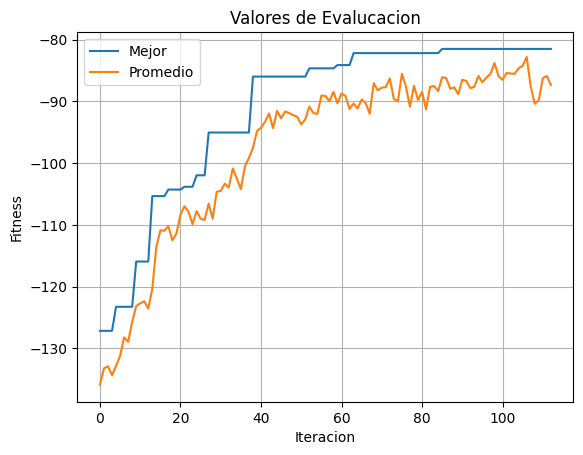

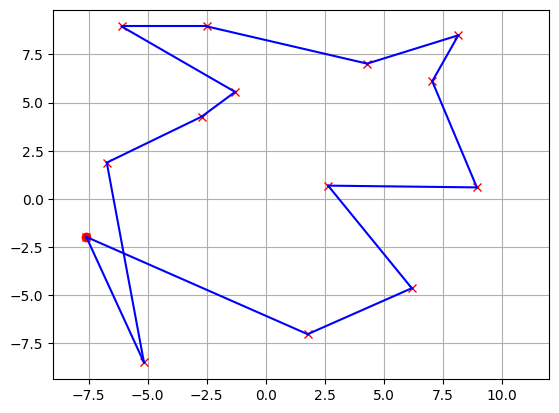

In [51]:
n = len(coordenadas)
Bounds =[(1,len(coordenadas)-1) for i in range(n-1)]
Enteras = [False]*len(Bounds)
f = fitness_ej1

cant_individuos = 10
cant_generac = 113
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_partial_map
cant_cruzados = round(0 * cant_individuos)
mut = mut_inversion
cant_mutados = round(0.30 * cant_individuos)
second_mut = mut_adjoin_swap
cant_segunda_mutacion = round(0.25 * cant_individuos)
max_iter_sin_mejora = 50

Pop = init_pop(cant_individuos, Bounds)
sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
     geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
         cant_cruzados, cant_mutados, cant_elite, eps, f, None, max_iter_sin_mejora, \
         second_mut, cant_segunda_mutacion)

print("Mejor solución: {0} (Fitness: {1})".format(sol, solF))
recorrido = sol.copy()
recorrido.insert(0,0)
recorrido.append(0)
print("Recorrido: {0}".format(recorrido))

graficarEvolucionFitness(traceBest, traceAvg)
graficarRecorrido(coordenadas, sol)

## Ejercicio 2

Se tiene una red de distribución eléctrica como la de la Figura, compuesta por un transformador trifásico que alimenta a N=20 clientes monofásicos. Un cliente solo puede estar conectado a una fase.

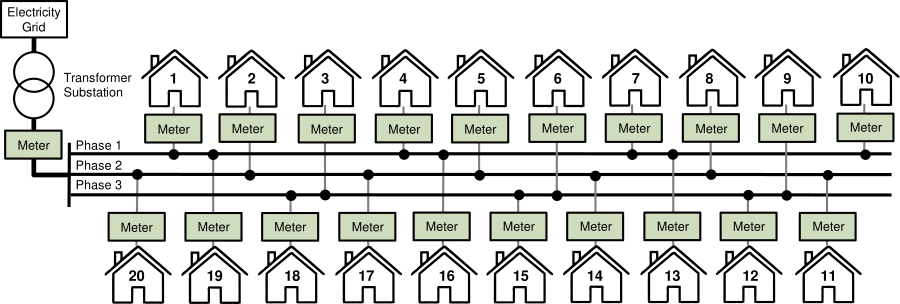








Cada cliente cuenta con un medidor inteligente que registra cuánta energía ha consumido durante un mes. Los valores de consumo son los siguentes:




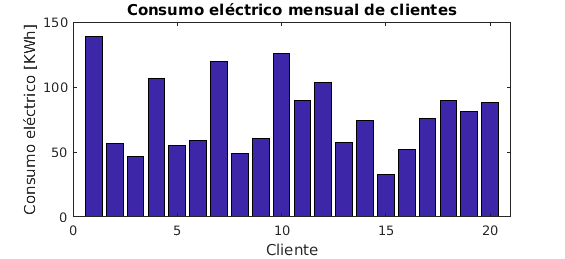




La energía total registrada en la fase "i" del transformador puede ser calculada sumando la energía consumida por todos los clientes conectados a dicha fase. Los consumos por fase son:




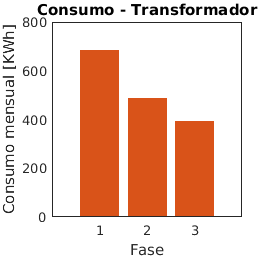




Debido a que existe una gran diferencia de consumo entre las fases, pueden ocurrir pérdidas de energía y se reduce la calidad del servicio eléctrico, entre otros inconvenientes.

Se pide resolver el problema de balance de carga, el cual consiste en equilibrar el valor del consumo eléctrico en cada una de las fases. Para lograrlo se pude cambiar de fase a algunos clientes. Dicho en otras palabras, se pide encontrar un nuevo esquema de conexión, de manera tal que el consumo total en cada fase sea aproximadamente el mismo.

Resuelva las siguientes dos variantes del problema:
1.  Teniendo en cuenta sólo reducir el desbalance de cargas en el transformador.
2.  Teniendo en cuenta reducir el desbalance con la mínima cantidad de cambios de fase.

Se pide:
*   Determine qué codificación utilizará para el problema (cómo representará las soluciones).
*   Diseñe una función de evaluación.
*   Seleccione los operadores genéticos adecuados para el problema.
*   Utilice un AG simple para encontrar una solución al problema.



In [52]:
#lista con valores de consumo para cada cliente.
consumos_iniciales = [138.49, 56.85, 46.56, 106.58, 54.62, 58.88, 119.36, 49.01, 60.48, 126.07, 89.31, 103.11, 57.18, 74.37, 32.46, 52.30, 75.53, 89.57, 81.36, 88.20]

#lista con valor de la fase donde se conecta el cliente.
fases_iniciales = [1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2]

def consumo_fases(consumos_clientes, fases_clientes):
    # Calcular el consumo total por fase a partir del consumo de clientes.
    # Parametros
    # - consumos_clientes: lista con valores de consumo para cada cliente.
    # - fases_clientes: lista con valor de la fase donde se conecta el cliente (valores 1,2 o 3).
    # - Devuelve vector con 3 elementos.
    consumos_fases = [0, 0, 0]
    for i, c in enumerate(consumos_clientes):
        consumos_fases[fases_clientes[i]-1] += c
    return consumos_fases


def indice_desbalance(consumo_fases):
    # Calcula el indice para medir el desbalance de las fases (más alto, más desbalanceado)
    return (max(consumo_fases) / (sum(consumo_fases)/3) - 1) * 100


def fitness_balance_carga(solucion):
    #### COMPLETAR ####
    # llamando a "consumo_fases"
    # llamando a "indice_desbalance"
    # fitness = ...
    fitness= indice_desbalance(consumo_fases(consumos_iniciales, solucion))
    return -fitness
def init_pop_ej2(cant_individuos, Bounds):
  return [[random.randint(B[0],B[1]) for B in Bounds] for i in range(cant_individuos)]


Primera variante solo reducir el desbalance de cargas en el transformador.


Mejor solución: [3, 1, 2, 2, 2, 2, 2, 2, 3, 1, 3, 1, 3, 1, 2, 2, 1, 3, 1, 3] (Fitness: -0.6024521082619305)
Consumo por fase : [517.29, 519.77, 523.23]
Índice de desbalance : 0.60%
Número de cambios de fase : 14


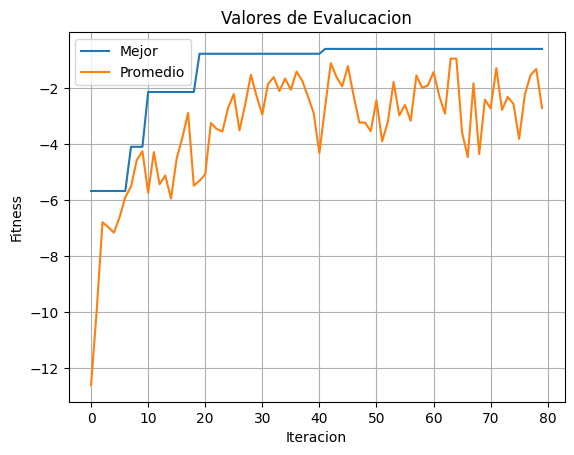

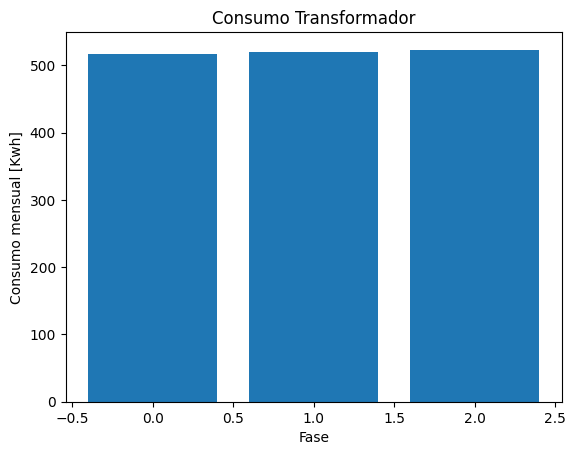

In [53]:
def num_cambios_fase(solucion_actual, fases_iniciales):
    # Calcula la cantidad de cambios de fase realizados.
    # Devuelve: el número de clientes cuya fase ha cambiado.
    cambios = 0
    for i in range(len(solucion_actual)):
        if solucion_actual[i] != fases_iniciales[i]:
            cambios += 1
    return cambios

# Configuración de hiperparámetros para la segunda variante
n = len(consumos_iniciales)
Bounds = [(1,3) for i in range(n)]
Enteras = [True]*len(Bounds)
f = fitness_balance_carga # Usar la nueva función de fitness

cant_individuos = 10
cant_generac = 80
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_one_point_crossover
cant_cruzados = round(0 * cant_individuos)
mut = mut_swap
cant_mutados = round(0.25 * cant_individuos)
second_mut = mut_adjoin_swap
cant_segunda_mutacion = round(0.25 * cant_individuos)
max_iter_sin_mejora = 50

Pop = init_pop_ej2(cant_individuos, Bounds)
sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
     geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
         cant_cruzados, cant_mutados, cant_elite, eps, f, None, max_iter_sin_mejora, \
         second_mut, cant_segunda_mutacion)

print("Mejor solución: {0} (Fitness: {1})".format(sol, solF))

# Calcular y mostrar métricas
consumo = consumo_fases(consumos_iniciales, sol)
print("Consumo por fase : {0}".format(consumo))
print("Índice de desbalance : {0:.2f}%".format(indice_desbalance(consumo)))
print("Número de cambios de fase : {0}".format(num_cambios_fase(sol, fases_iniciales)))

graficarEvolucionFitness(traceBest, traceAvg)

plt.figure()
plt.bar(range(len(consumo)), [p for p in consumo])
plt.title('Consumo Transformador')
plt.xlabel('Fase')
plt.ylabel('Consumo mensual [Kwh]')
plt.show()

Segunda variante : Reducir el desbalance con la mínima cantidad de cambios de fase.

Mejor solución: [2, 3, 2, 3, 2, 3, 3, 1, 1, 1, 3, 2, 2, 1, 2, 1, 1, 2, 1, 3] (Fitness: -28.36403489094976)
Consumo por fase : [519.12, 521.99, 519.1800000000001]
Índice de desbalance : 0.36%
Número de cambios de fase : 15


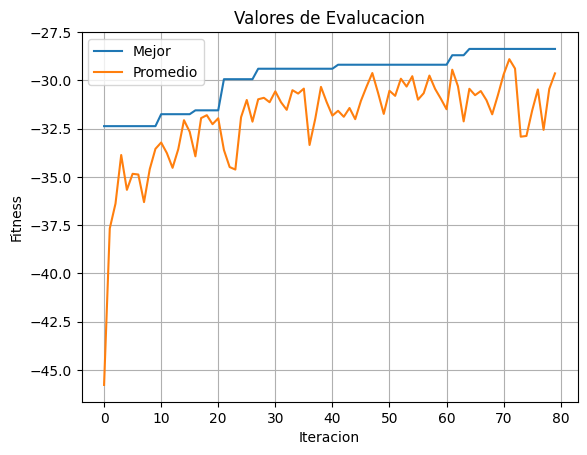

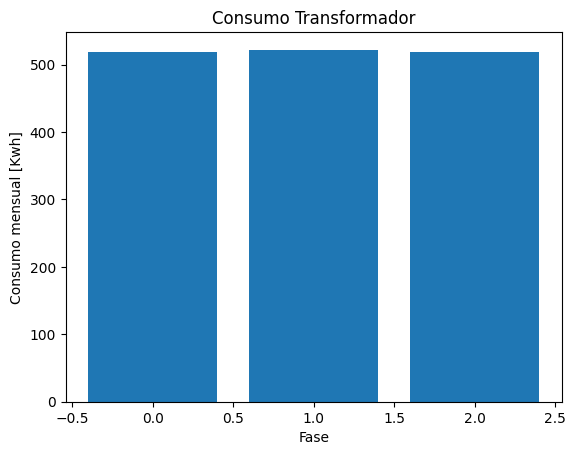

In [57]:
def fitness_multiObjetivo(individuo):

  return fitness_balance_carga(individuo) -2*num_cambios_fase(sol,fases_iniciales)
n = len(consumos_iniciales)
Bounds = [(1,3) for i in range(n)]
Enteras = [True]*len(Bounds)
f = fitness_multiObjetivo# Usar la nueva función de fitness

cant_individuos = 10
cant_generac = 80
cant_elite = 1
sel = sel_sus
eps = 0.1
xover = xov_one_point_crossover
cant_cruzados = round(0 * cant_individuos)
mut = mut_swap
cant_mutados = round(0.25 * cant_individuos)
second_mut = mut_adjoin_swap
cant_segunda_mutacion = round(0.25 * cant_individuos)
max_iter_sin_mejora = 50

Pop = init_pop_ej2(cant_individuos, Bounds)
sol, solF, Pop, Fit, traceBest, traceAvg, bestSols = \
     geneticoSimple(Pop, cant_generac, Bounds, Enteras, sel, xover, mut, \
         cant_cruzados, cant_mutados, cant_elite, eps, f, None, max_iter_sin_mejora, \
         second_mut, cant_segunda_mutacion)

print("Mejor solución: {0} (Fitness: {1})".format(sol, solF))

# Calcular y mostrar métricas
consumo = consumo_fases(consumos_iniciales, sol)
print("Consumo por fase : {0}".format(consumo))
print("Índice de desbalance : {0:.2f}%".format(indice_desbalance(consumo)))
print("Número de cambios de fase : {0}".format(num_cambios_fase(sol, fases_iniciales)))

graficarEvolucionFitness(traceBest, traceAvg)

plt.figure()
plt.bar(range(len(consumo)), [p for p in consumo])
plt.title('Consumo Transformador')
plt.xlabel('Fase')
plt.ylabel('Consumo mensual [Kwh]')
plt.show()